# Seminar 1: Probability & Bayes, MLE & MAP

## A Minute of Theory

### Conditional Probability

Let there be two events $A$ and $B$. Then conditional probability is introduced as follows (axiomatically):



$$p(A|B) = \frac{p(A, B)}{p(B)}$$



This is the probability that event $A$ occurs given that event $B$ has already occurred.

If $p(A|B) = p(A)$, then we say that event $A$ does not depend on $B$.

---

### Bayes’ Formula

Bayes’ formula follows from the definition of conditional probability in two simple steps:
$$p(A|B) = \frac{p(A, B)}{p(B)} = \frac{p(A) p(B|A)}{p(B)}$$

# Problem 1. A Warm‑Up for the Brain

A family has two children. Each child is either a boy or a girl with an equal probability of 50%.

Then the full sample space of events is described by four outcomes.

![](full_space_boy_girl.png)

#### If all we know is that the family has two children, what is the probability that both are boys?
$$p(bb) = \frac{1}{2} \frac{1}{2} = \frac{1}{4}$$
![](two_boys.png)

#### If it is known that one of the children is a boy, what is the probability that the other child is also a boy?

$$p(bb | b) = \frac{p(bb) p(b | bb)}{p(b)} = \frac{\frac{1}{4} \cdot 1}{\frac{3}{4}} = \frac{1}{3}$$

$p(b)$ — the probability that there is at least one boy.

![](one_is_a_boy.png)

#### If it is known that the older child is a boy, what is the probability that the younger child is also a boy?

$$p(bb | b_{old} ) = \frac{p(bb) p(b_{old} | bb)}{p(b_{old})} = \frac{\frac{1}{4} \cdot 1}{\frac{1}{2}} = \frac{1}{2}$$

The difference between the previous example and this one is that we have now fixed the order of the children, which significantly affects the probabilities because it explicitly determines the column (see the picture).

![](old_is_boy.png)

#### If it is known that one of the children is a boy who was born on Tuesday, what is the probability that the other child is also a boy?

$$p(bb | b_{tuesday} ) = \frac{p(bb) p(b_{tuesday} | bb)}{p(b_{tuesday})}$$

The probability that at least one boy was born on Tuesday is (1 - the probability that none of them were born on Tuesday).

$$p(b_{tuesday} | bb) = \left(1 - \left(1 - \frac{1}{7}\right)^2\right) = \frac{13}{49}$$


we compute $p(b_{tuesday})$:

$$p(b_{tuesday}) =  p(b_{tuesday} | bg) * p(bg) + p(b_{tuesday} | gb) * p(gb) + p(b_{tuesday} | gg) * p(gg) + p(b_{tuesday} | bb) * p(bb)$$
$$= \frac{1}{4} \frac{1}{7} + \frac{1}{4} \frac{1}{7} + 0 +  \frac{1}{4} p(b_{tuesday} | bb) = \frac{27}{196}$$

then:

$$p(bb | b_{tuesday} ) = \frac{\frac{1}{4} \frac{13}{49}}{\frac{27}{196}} = \frac{13}{27} \approx 0.481$$

#### We were walking past a family’s house and saw a boy in the window; what is the probability that the other child is also a boy?

$$p(b) = \frac{1}{2}$$

![](one_is_a_boy_obs.png)

Important point!

Knowing a priori that one child is a boy is not the same as observing that one of the children is a boy, because in the second case we implicitly fix an order between the children (“the child we observed first” and “the other child”). In this sense, the situation becomes similar to the example with “the older child is a boy.” This is an example showing that the order can be fixed in many different ways.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

sns.set(font_scale=2)

# Problem 2. Now we are geneticists.

According to Darwin, fitness is the central concept of evolutionary theory.

Let us define *relative fitness* as the ratio of the average number of surviving individuals of one genotype to the average number of surviving individuals of another genotype.

Eyre-Walker (2006) (https://www.ncbi.nlm.nih.gov/pubmed/16547091) proposed that the fitness function belongs to the family of gamma‑distributed random variables.

They tested this assumption by fitting the number of mutations in humans that lead to the generation of “deleterious” amino acids (those that worsen our condition), and obtained the following estimates for the parameters of the gamma distribution:

$$\hat{\alpha} = 0.23,~~~ \hat{\beta} = 5.35$$


$$\Gamma(x|\alpha, \beta) =  \frac{\beta^\alpha}{\Gamma(\alpha)} x^{\alpha-1} \exp(-\beta x),$$

where $\Gamma(\alpha)$ -- is the Euler gamma function (for integer $\alpha$: $\Gamma(\alpha) = (\alpha-1)!$)

#### What question will we ask?

If we estimate the parameters $\alpha$ and $\beta$ from a random sample, how large is our average estimation error when the sample size is $N=100$?

In other words, we are interested in two things: the **variances** of our estimates and the **correlation** of the estimates.

We will evaluate them using the following algorithm:

1. Sample a dataset $X \sim \Gamma(x|\hat{\alpha}, \hat{\beta})$
2. Estimate $\alpha_{fit}, \beta_{fit}$ from the sample $X$
3. Store $\alpha_{fit}, \beta_{fit}$
4. Repeat steps 1–3 $N$ times
5. Compute the variances and correlations of $\{\alpha_{fit}, \beta_{fit}\}_{i=1}^{N}$


## 2.1 Maximum Likelihood Estimation Method

MLE (Maximum Likelihood Estimation) is based on maximizing the probability of observing the sample.

$$\mathcal{L} = \prod_{i=1}^N p(x_i|\theta)$$

We will consider MLE using the example from the previous problem.


In [2]:
from scipy.stats import gamma

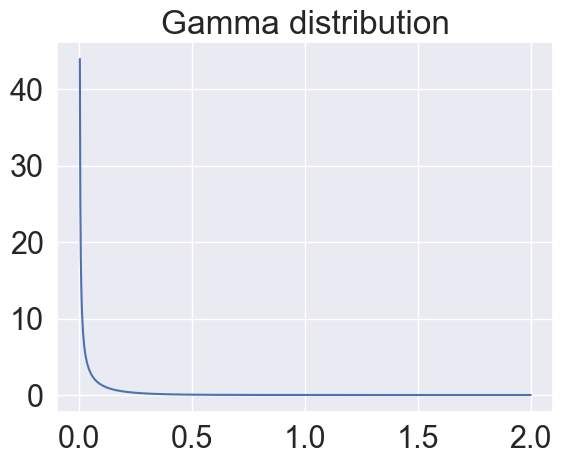

In [6]:
# scale == \theta
# In SciPy, every distribution is parameterized with an additional shift (loc) and scale (scale) parameter.
x = np.linspace(0, 2, 1000)
alpha = 0.23
beta = 5.35

plt.figure()
plt.plot(x,gamma.pdf(x, scale=1 / beta, a=alpha, loc = 0))
plt.title("Gamma distribution")
plt.show()

In [7]:
np.random.seed(1337)
X = gamma.rvs(scale=1 / beta, a=alpha, size=100)

In [127]:
gamma.pdf(X[0], scale=1 / beta, a=alpha)

np.float64(119.31210382989336)

In [8]:
np.prod(gamma.pdf(X, scale=1 / beta, a=2.5))

np.float64(1.653645679480908e-267)

The likelihood equation is most often written using the logarithm of the probability, since in this case the product turns into a sum, which greatly simplifies things.

$$\log \mathcal{L} = \sum\limits_i \log p(x_i|\theta)$$

- **better numerical stability** (prevents overflow and underflow errors);
- **more (relatively) accurate gradients**;
- **a smoother optimization problem** (optimization methods work better).

Let us look at the log-likelihood for our problem with the gamma distribution.

$$\mathcal{L} = \prod\limits_i \frac{\beta^\alpha}{\Gamma(\alpha)} x_i^{\alpha-1} \exp(-\beta x_i)$$

$$\log \mathcal{L} = \sum\limits_i \left( \alpha \log \beta - \log \Gamma(\alpha) - \beta x_i + (\alpha - 1) \log x_i \right)$$

(Note how simple the dependence on $x_i$ has become :)


In [9]:
a = np.linspace(0, 1, 200)
likelihood = np.prod(
    gamma.pdf(
        X[:, np.newaxis], 
        scale=1 / beta, 
        a=a), 
        axis=0
)

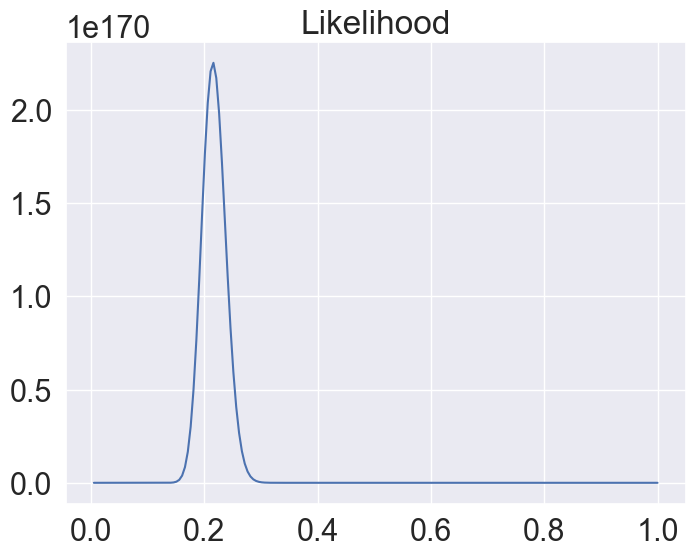

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(a, likelihood)
plt.title('Likelihood')
plt.show()

Text(0.5, 1.0, 'Log-Likelihood')

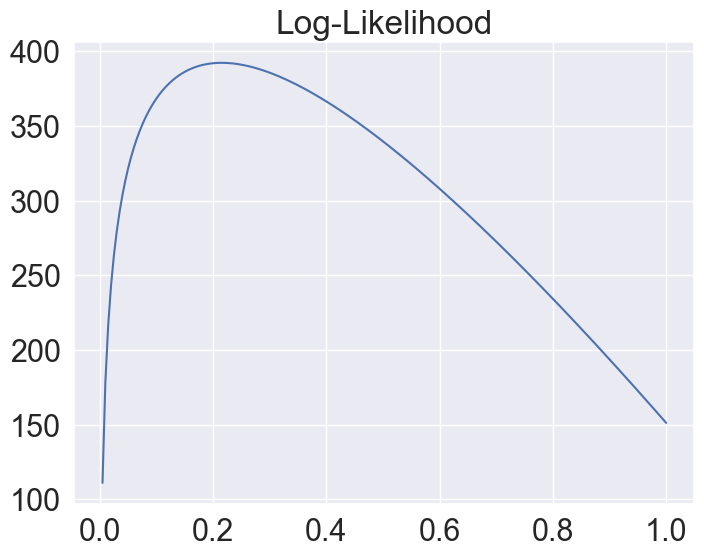

In [11]:
log_likelihood = np.sum(gamma.logpdf(X[:, np.newaxis], 
                        scale=1 / beta, 
                        a=a), 
            axis=0)

plt.figure(figsize=(8, 6))
plt.plot(a, log_likelihood)
plt.title('Log-Likelihood')

### MLE? MLE!

In most real problems (as opposed to toy examples), finding a closed‑form expression for the MLE estimates is very difficult.

$$\theta^* = \arg \max_\theta \log \mathcal{L}(X, \theta)$$

We take the first derivative with respect to each parameter of the distribution and set it to zero:

$$\frac{\partial}{\partial \theta} \log \mathcal{L}(X, \theta) = 0$$

For the parameter $\beta$ of the gamma distribution:

$$\frac{\partial}{\partial \beta} \log \mathcal{L} = \sum_i \left(\frac{\alpha}{\beta} - x_i\right) = 0$$

$$\beta = \frac{\alpha N}{\sum_i x_i}$$

For the parameter $\alpha$:

$$\frac{\partial}{\partial \alpha} \log \mathcal{L} = N \log \beta + \sum_i \log x_i - N\,\psi(\alpha) = 0$$

This leads to the equation:

$$\psi(\alpha) = \log \beta + \frac{1}{N} \sum \log x_i$$

which **cannot be solved in closed form**.

Thus, the MLE system becomes:

$$\beta = \frac{\alpha}{\bar{x}}$$

$$\psi(\alpha) = \log \beta + \frac{1}{N} \sum \log x_i$$

Unfortunately, there is no analytic solution.

Thank goodness for open‑source software!


In [12]:
(alpha, loc_hat, scale_hat) = gamma.fit(X, floc = 0)
beta = 1 / scale_hat
print(alpha, beta)

0.2313491743258105 7.52708487472913


## It's time to experiment :)

In [20]:
%%time
boot = 10000
alphas = []
betas = []
fitted_alphas = []
fitted_betas = []
for i in range(boot):
    X = gamma.rvs(scale=1 / beta, a=alpha, size=1000)
    fit_alpha, _, fit_beta = gamma.fit(X, floc=0)
    fitted_betas.append(1 / fit_beta)
    fitted_alphas.append(fit_alpha)

CPU times: total: 1.84 s
Wall time: 1.88 s


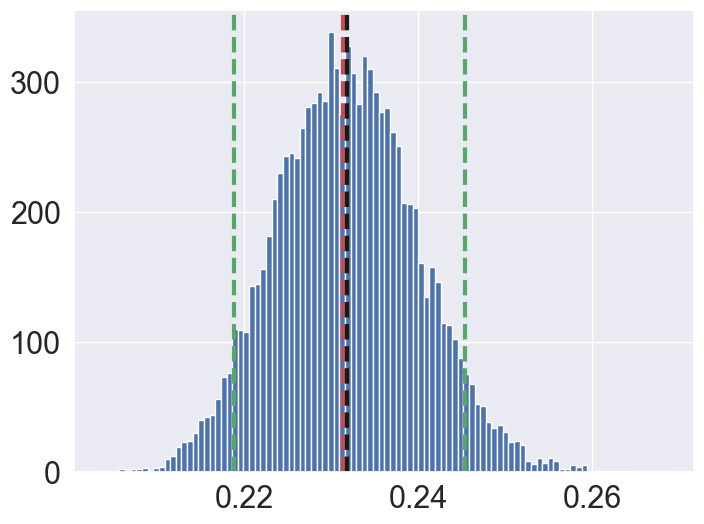

In [21]:
plt.figure(figsize=(8, 6))

plt.hist(fitted_alphas, bins=100);
alpha_q5, alhpa_q95 = np.percentile(fitted_alphas, [5, 95])
plt.axvline(x=alpha, linewidth=3, color='r',linestyle='--')
plt.axvline(x=np.mean(fitted_alphas), linewidth=3, color='k',linestyle='--')
plt.axvline(x=alpha_q5, linewidth=3, color='g',linestyle='--')
plt.axvline(x=alhpa_q95, linewidth=3, color='g',linestyle='--')

plt.show()

In [22]:
np.mean(np.array(fitted_alphas) - alpha)

np.float64(0.0004726781178720432)

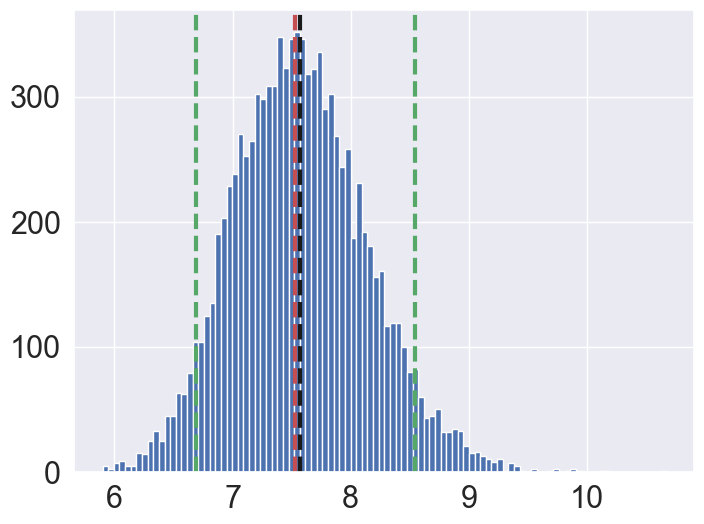

In [23]:
plt.figure(figsize=(8, 6))

plt.hist(fitted_betas, bins=100);
beta_q5, beta_q95 = np.percentile(fitted_betas, [5, 95])
plt.axvline(x=beta, linewidth=3, color='r',linestyle='--')
plt.axvline(x=np.mean(fitted_betas), linewidth=3, color='k',linestyle='--')
plt.axvline(x=beta_q5, linewidth=3, color='g',linestyle='--')
plt.axvline(x=beta_q95, linewidth=3, color='g',linestyle='--')

plt.show()

In [24]:
np.mean(np.array(fitted_betas) - beta)

np.float64(0.045935389540746684)

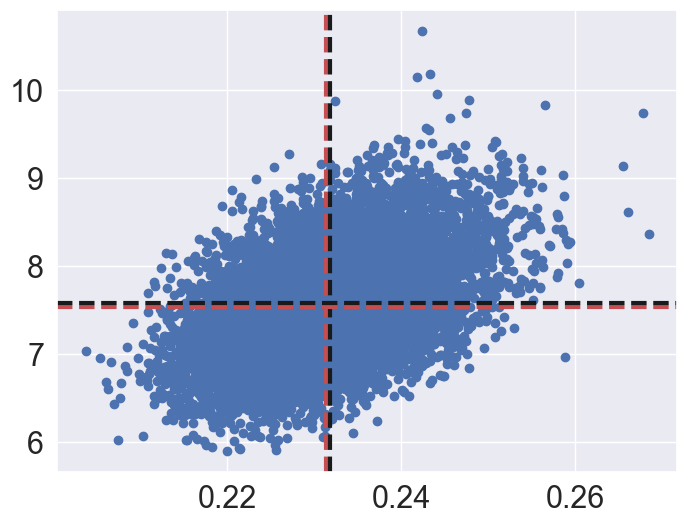

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(fitted_alphas, fitted_betas)
plt.axvline(x=alpha, linewidth=3, color='r',linestyle='--')
plt.axvline(x=np.mean(fitted_alphas), linewidth=3, color='k', linestyle='--')
plt.axhline(y=beta, linewidth=3, color='r',linestyle='--')
plt.axhline(y=np.mean(fitted_betas), linewidth=3, color='k', linestyle='--')

plt.show()

In [26]:
np.mean(fitted_alphas)

np.float64(0.23182185244368256)

In [27]:
np.corrcoef(fitted_alphas, fitted_betas)

array([[1.        , 0.46772893],
       [0.46772893, 1.        ]])

In [28]:
from scipy.stats import pearsonr
pearsonr(fitted_alphas, fitted_betas)

PearsonRResult(statistic=np.float64(0.46772892933758736), pvalue=np.float64(0.0))

### Bias Estimation

As we can see, the MLE produced a biased estimate. This happens because MLE provides a consistent, **asymptotically** efficient, and **asymptotically** normal estimator.


In [29]:
%%time
boot = 10000
sizes = np.logspace(1, 3, 10).astype(int)

bias_alphas = []
bias_betas = []

for size in sizes:
    fitted_alphas = []
    fitted_betas = []
    for i in range(boot):
        X = gamma.rvs(scale=1 / beta, a=alpha, size=size)
        fit_alpha, _, fit_beta = gamma.fit(X, floc=0)
        fitted_betas.append(1 / fit_beta)
        fitted_alphas.append(fit_alpha)
        
    bias_alphas.append(np.mean(fitted_alphas) - alpha)
    bias_betas.append(np.mean(fitted_betas) - beta)

CPU times: total: 12.9 s
Wall time: 13.2 s


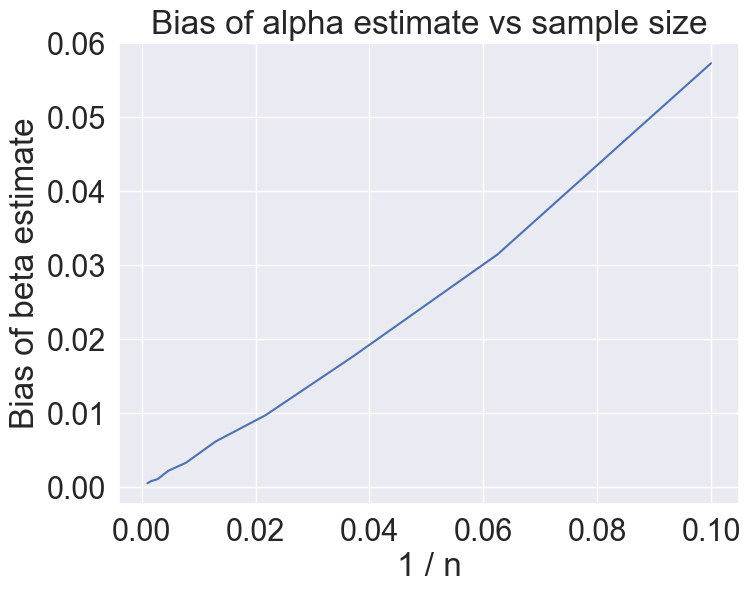

In [30]:
plt.figure(figsize=(8, 6))
plt.title("Bias of alpha estimate vs sample size")
plt.xlabel("1 / n")
plt.ylabel("Bias of beta estimate")
plt.plot(1 / sizes, bias_alphas);


plt.show()

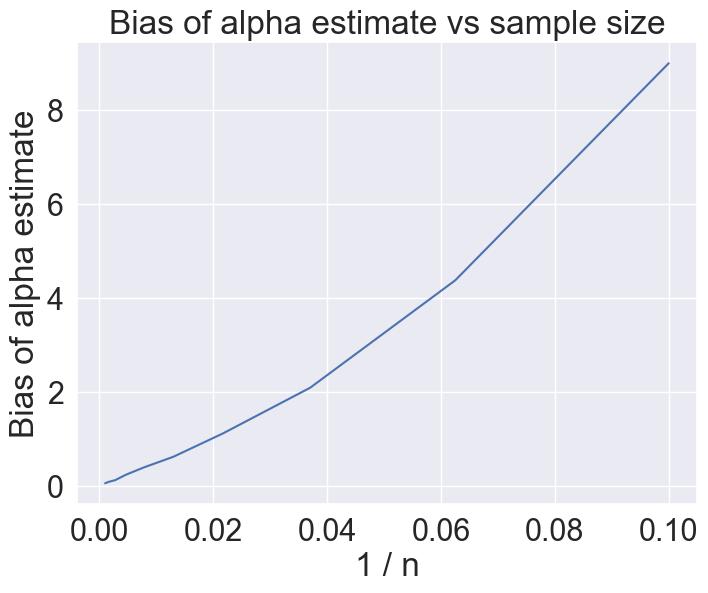

In [31]:
plt.figure(figsize=(8, 6))
plt.title("Bias of alpha estimate vs sample size")
plt.xlabel("1 / n")
plt.ylabel("Bias of alpha estimate")
plt.plot(1 / sizes, bias_betas);

plt.show()

As we can see, $\textrm{bias} \sim \frac{1}{n}$.

### Is this a problem?

It depends on the context, but in general MLE estimators are $\sqrt{n}$‑consistent, meaning that the variance of the estimator decreases much more slowly than the bias. Therefore, the variance almost always dominates the observed bias (compare the width of the histogram with the position of the bias in the plots above).

### What if you still want to remove the bias?

1. Compute the bias analytically:
   $$\mathrm{bias} = E_{p(X | \theta)}\, \theta_{MLE} - \theta$$

#### Example

As an example, consider the uniform distribution:  $x_i \sim U[0, a]$.

$$\log p(x|a) = - \sum_{x_i} \log a = - n \log a$$

$$\frac{d}{d a} \log p(x|a) = -\frac{n}{a}$$

Since the derivative is monotonic (i.e., the likelihood reaches its maximum at the boundary of the interval), the MLE estimator is:

$$a_{MLE} = \max_i x_i$$

Now let us compute the bias of the MLE. First, write down the distribution function of the maximum:

$$P(\max_i x_i < T) = P(x_1 < T) P(x_2 < T) \dots P(x_n < T)
= \left( \frac{T}{a} \right)^n$$

The density of the maximum:

$$p(\max_i x_i) = \frac{d}{dT} P(\max_i x_i < T)
= n \left( \frac{T}{a} \right)^{n-1} \frac{1}{a}$$

Now compute the bias analytically:

$$E_{p(\max_i x_i | a)}\, a_{MLE}
= \int n\, a_{MLE} \left( \frac{a_{MLE}}{a} \right)^{n-1} \frac{1}{a}\, da_{MLE}
= \frac{n}{n+1}\, a$$

Thus, to correct the bias you only need to multiply by  $\frac{n+1}{n} a_{MLE}$.

2. If computing the bias analytically is difficult, you can use the bootstrap.  
   If the likelihood is smooth, the jackknife bootstrap works very well.

3. More exotic methods: Cox–Snell correction:

https://www.jstor.org/stable/2984505  
https://journal.r-project.org/archive/2017/RJ-2017-055/RJ-2017-055.pdf

(1) requires substantial manual calculations,  
(2) requires more computational power,  
(3) is computationally light and does not require analytic derivations,  
but it removes only the $(1/n)$‑bias; for finer corrections ($1/n^2$, etc.) the procedure must be applied iteratively.


## 2.2 Method of Moments

With the gamma distribution we are lucky that `scipy` provides a method for likelihood fitting. But what if it didn’t?.. For example, if we invented a new distribution for which directly optimizing the likelihood is very difficult.

If we want to determine the parameters of some distribution $p(x \mid \theta) $, we can equate the moments of this distribution to the moments computed from the data  
$X = \{ x_1, \dots, x_n \} $ and solve the resulting equations with respect to these moments.

The sample moments are computed as follows:

$$\hat{\mu}_k = \frac{1}{n} \sum_{i=1}^{n} x_i^k$$

The theoretical moments of the distribution:

$$\mu_k = \sum\limits_{i=1}^{n} x^k p(x | \theta) dx$$

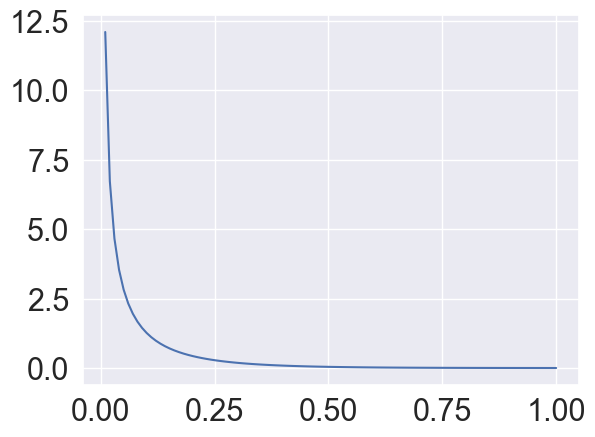

In [145]:
from scipy.stats import gamma
x = np.linspace(0, 1, 100)
alpha = 0.23
beta = 5.35
plt.plot(x, gamma.pdf(x, scale=1 / beta, a=alpha))

The mean and variance of the gamma distribution:

$$\mu(\Gamma) = \frac{\alpha}{\beta}$$

$$Var(\Gamma) = \frac{\alpha}{\beta^2}$$

Applying the method of moments:

$$\hat{\mu}_1 = \frac{\alpha}{\beta}$$

$$\hat{\mu}_2 = \frac{\alpha^2}{\beta^2} + \frac{\alpha}{\beta^2}$$

Solving this system of equations, we obtain:

$$\beta = \frac{\hat{\mu}_1}{\hat{\mu}_2 - \hat{\mu}_1^2}$$

$$\alpha = \hat{\mu}_1 \beta$$


In [32]:
%%time
boot = 10000
fitted_alphas = []
fitted_betas = []
for i in range(boot):
    X = gamma.rvs(scale=1 / beta, a=alpha, size=100)
    mu_1 = X.mean()
    mu_2 = np.square(X).mean()
    fitted_betas.append(
        mu_1 / (mu_2 - mu_1**2)
    )
    
    fitted_alphas.append(
        mu_1**2 / (mu_2 - mu_1**2)
    )

CPU times: total: 672 ms
Wall time: 718 ms


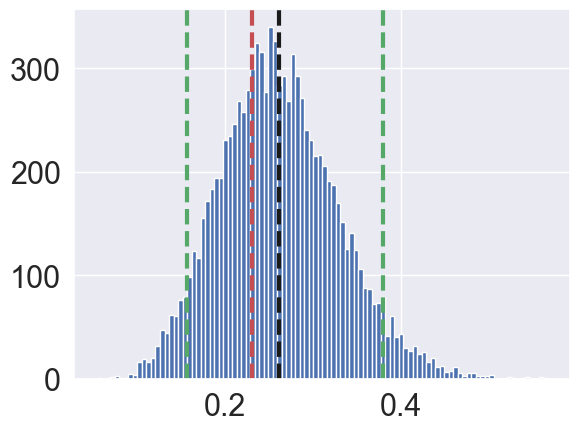

In [34]:
plt.hist(fitted_alphas, bins=100);
alpha_q5, alhpa_q95 = np.percentile(fitted_alphas, [5, 95])
plt.axvline(x=alpha, linewidth=3, color='r',linestyle='--')
plt.axvline(x=np.mean(fitted_alphas), linewidth=3, color='k',linestyle='--')
plt.axvline(x=alpha_q5, linewidth=3, color='g',linestyle='--')
plt.axvline(x=alhpa_q95, linewidth=3, color='g',linestyle='--')

In [35]:
np.mean(np.array(fitted_alphas) - alpha)

np.float64(0.030566339698386385)

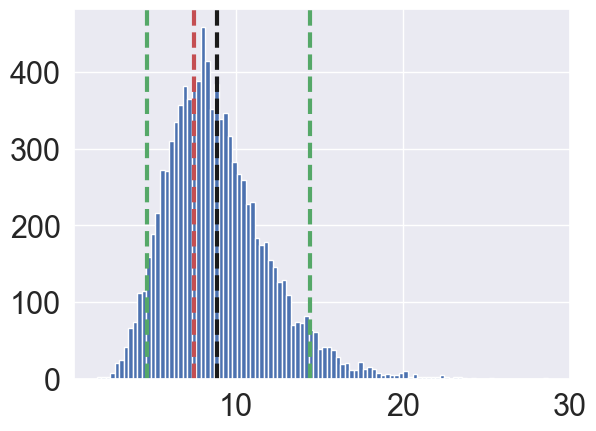

In [37]:
plt.hist(fitted_betas, bins=100);
beta_q5, beta_q95 = np.percentile(fitted_betas, [5, 95])
plt.axvline(x=beta, linewidth=3, color='r',linestyle='--')
plt.axvline(x=np.mean(fitted_betas), linewidth=3, color='k',linestyle='--')
plt.axvline(x=beta_q5, linewidth=3, color='g',linestyle='--')
plt.axvline(x=beta_q95, linewidth=3, color='g',linestyle='--')

In [38]:
np.mean(np.array(fitted_betas) - beta)

np.float64(1.3727084974264885)

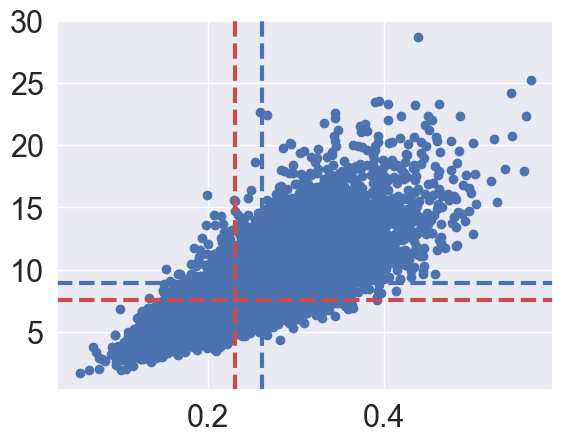

In [39]:
plt.scatter(fitted_alphas, fitted_betas)
plt.axvline(x=alpha, linewidth=3, color='r',linestyle='--')
plt.axvline(x=np.mean(fitted_alphas), linewidth=3, color='b', linestyle='--')
plt.axhline(y=beta, linewidth=3, color='r',linestyle='--')
plt.axhline(y=np.mean(fitted_betas), linewidth=3, color='b', linestyle='--')

In [40]:
from scipy.stats import pearsonr
np.corrcoef(fitted_alphas, fitted_betas)

array([[1.        , 0.75557487],
       [0.75557487, 1.        ]])

In [41]:
pearsonr(fitted_alphas, fitted_betas)

PearsonRResult(statistic=np.float64(0.7555748681538392), pvalue=np.float64(0.0))

### Estimating the bias of the method of moments

In [42]:
%%time
boot = 10000
sizes = np.logspace(1, 3, 10).astype(int)

bias_alphas = []
bias_betas = []

for size in sizes:
    fitted_alphas = []
    fitted_betas = []
    for i in range(boot):
        X = gamma.rvs(scale=1 / beta, a=alpha, size=size)
        mu_1 = X.mean()
        mu_2 = np.square(X).mean()
        fitted_betas.append(
            mu_1 / (mu_2 - mu_1**2)
        )

        fitted_alphas.append(
            mu_1**2 / (mu_2 - mu_1**2)
        )
        
    bias_alphas.append(np.mean(fitted_alphas) - alpha)
    bias_betas.append(np.mean(fitted_betas) - beta)

CPU times: total: 7.95 s
Wall time: 8.1 s


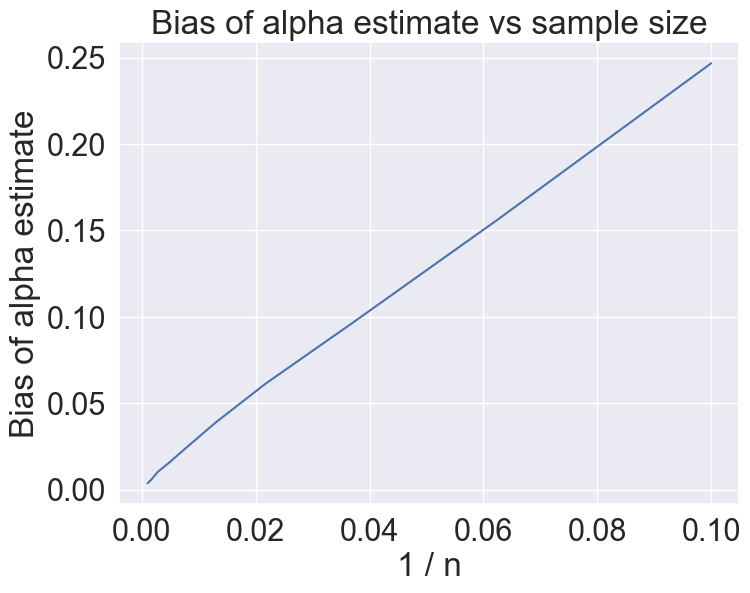

In [43]:
plt.figure(figsize=(8, 6))
plt.title("Bias of alpha estimate vs sample size")
plt.xlabel("1 / n")
plt.ylabel("Bias of alpha estimate")
plt.plot(1 / sizes, bias_alphas);

plt.show()

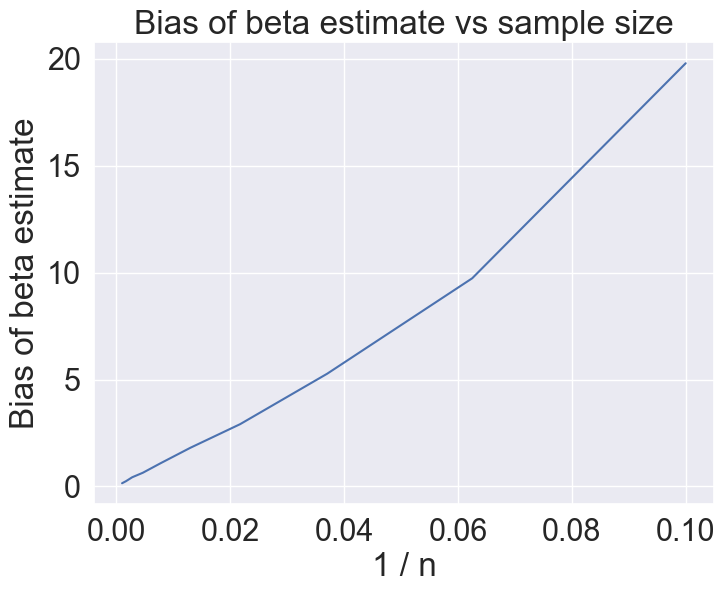

In [44]:
plt.figure(figsize=(8, 6))
plt.title("Bias of beta estimate vs sample size")
plt.xlabel("1 / n")
plt.ylabel("Bias of beta estimate")
plt.plot(1 / sizes, bias_betas);

plt.show()

## Conclusions

What can we say after comparing the method of moments with the MLE estimator? How do they relate to each other?

When should we use the Method of Moments (MoM)?

1. For quick parameter estimates when the MLE does not have a closed‑form analytical solution.
2. For initializing parameters in more advanced optimization methods.
3. For estimating causal effects (a developing area):
    1. https://papers.nips.cc/paper/2019/file/15d185eaa7c954e77f5343d941e25fbd-Paper.pdf


# 3. MAP

Suppose you flipped a coin once and it came up heads.

The distribution is described by the Bernoulli model: $p(x=1, q) = q$.

For a sample $x_1, x_2, \dots, x_N$, the likelihood is written as follows:

$$p(X| q) = \prod q^{x_i} (1 - q)^{1-x_i}$$

$$\log p(X| q) = \sum\left[ x_i \log q + (1 - x_i) \log(1 - q) \right]$$

The parameter estimate is obtained as follows:

$$\frac{\partial }{\partial q} \log p(X| q) = \frac{1}{q} \sum x_i - \frac{1}{1-q} \sum (1 - x_i) = 0$$

We obtain:

$$q = \frac{\sum x_i}{n}$$

According to the maximum likelihood principle, this gives $q=1$, i.e., it suggests that the coin will always land heads.

Such an estimate does not align very well with reality.


However, you have some prior knowledge. You know for sure that a fair coin lands heads 50% of the time.

Can we somehow use this? Yes — this is achieved by introducing a prior distribution.

In MLE, the parameters were estimated by maximizing the likelihood:

$$q = \mathrm{argmax} \log P(X | q) = \mathrm{argmax} \sum \log p(x_i, q) $$

In MAP we introduce a distribution $P(q)$ — our prior knowledge about the parameter. In MAP we maximize the posterior probability $p(q | X)$:

$$
q = \mathrm{argmax} \, P(X | q) P(q) = \mathrm{argmax} \left( \sum \log p(x_i, q) \right) P(q)
$$


Let us return to the coin.

As a prior distribution, we choose the Beta distribution with the following density:

$$P(q | \alpha, \beta) = \frac{1}{B(\alpha, \beta)} q^{\alpha - 1} (1 - q)^{\beta - 1}$$

![beta](https://upload.wikimedia.org/wikipedia/commons/thumb/f/f3/Beta_distribution_pdf.svg/531px-Beta_distribution_pdf.svg.png)

In this case, the posterior density takes the following form:

$$p(X, q) p(q) = \prod q^{x_i} (1 - q)^{1-x_i} \frac{1}{B(\alpha, \beta)} q^{\alpha - 1} (1 - q)^{\beta - 1}$$

Log‑probability:

$$\log p(X, q) p(q) = (\alpha - 1) \log q + (\beta - 1) \log (1 - q) +  \sum\left[ x_i \log q + (1 - x_i) \log(1 - q) \right] $$

We optimize the expression by setting the derivative to zero:

$$\frac{\partial }{\partial q} \log p(X, q) p(q) = $$

$$ = \frac{1}{q} \sum x_i - \frac{1}{1-q} \sum (1 - x_i) + \frac{\alpha - 1}{q} - \frac{\beta - 1}{1 - q} = 0$$


Solving the equation above, we obtain:

$$q = \frac{\sum x_i + \alpha - 1}{n + \beta + \alpha - 2}$$

Let our prior be $\alpha = \beta = 2$ (see the figure above).

Then, after a single coin flip, we get the following estimate:

$$q = \frac{1 + 2 - 1}{1 + 2 + 2 - 2} = \frac{2}{3} \approx 0.66$$

### What is the physical meaning of $\alpha$ and $\beta$?

By introducing the prior $P(q \mid \alpha, \beta)$, we effectively add  
$\alpha - 1$ “virtual” coin flips that resulted in heads  
$\beta - 1$ “virtual” coin flips that resulted in tails.


### Let us run a small experiment with $q = 0.4$ and compare MLE and MAP with different priors


In [45]:
q = 0.4
coin_flips = np.random.binomial(n=1, p=q, size=1000)

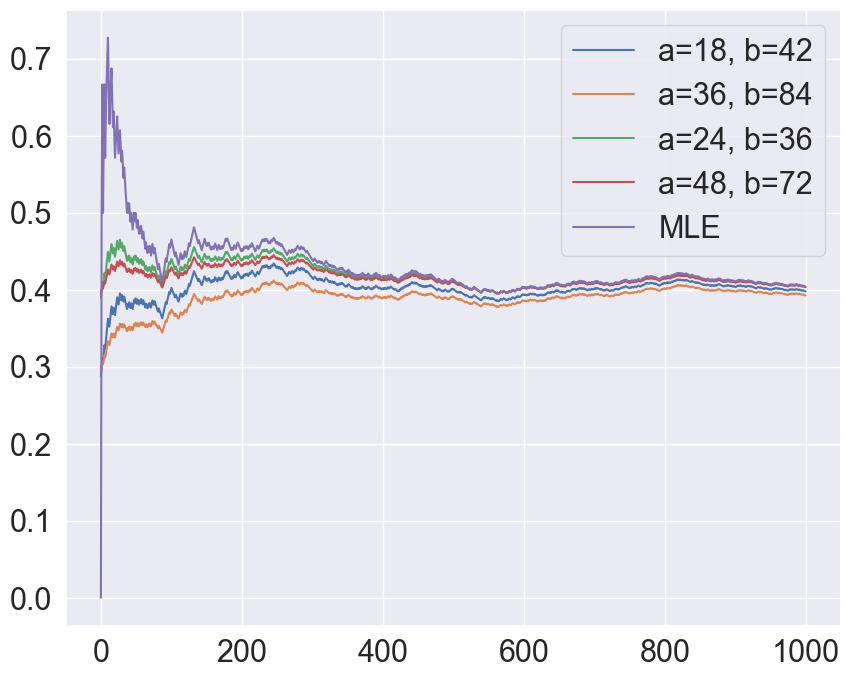

In [46]:
plt.figure(figsize=(10, 8), dpi=100)

a = 18
b = 42
plt.plot((np.cumsum(coin_flips) + a - 1) / (np.cumsum(np.ones_like(coin_flips)) + b + a - 2), label="a={}, b={}".format(a, b))

a = 36
b = 84
plt.plot((np.cumsum(coin_flips) + a - 1) / (np.cumsum(np.ones_like(coin_flips)) + b + a - 2), label="a={}, b={}".format(a, b))

a = 24
b = 36
plt.plot((np.cumsum(coin_flips) + a - 1) / (np.cumsum(np.ones_like(coin_flips)) + b + a - 2), label="a={}, b={}".format(a, b))

a = 48
b = 72
plt.plot((np.cumsum(coin_flips) + a - 1) / (np.cumsum(np.ones_like(coin_flips)) + b + a - 2), label="a={}, b={}".format(a, b))

plt.plot(np.cumsum(coin_flips) / np.cumsum(np.ones_like(coin_flips)), label="MLE")

plt.legend()
plt.show()

### Conclusions

1. When the sample size is large, MLE performs better than a poor prior.
2. When the sample size is very small (<10), even a poor prior is better than having no prior at all.
3. For a medium‑sized sample, there is little difference between MLE and a poor prior.
4. In all cases, a good prior outperforms everything else (but how do we find one?..).


## One of the differences between the Bayesian and frequentist approaches

For Bayesian analysis, let us assume that we have a flat prior, i.e. \( p(q) = 1 \).

Now let us perform a change of variables:

$$q = t^2$$

What changes?

### MLE

$$p(X | q) = \prod q^{x_i} (1 - q)^{1-x_i} \Rightarrow p(X, t) = \prod (t^2)^{x_i} (1 - t^2)^{1-x_i}$$

Nothing changes.


### MAP

$$p(X | q) = \prod q^{x_i} (1 - q)^{1-x_i} \Rightarrow p(X, t) = \prod (t^2)^{x_i} (1 - t^2)^{1-x_i}$$

$$p(q) = 1 \Rightarrow p(t) = 1$$

So again, nothing seems to change?! What did I do wrong?

### What exactly did I do wrong?

This is a semi‑philosophical, semi‑mathematical issue.

In MLE we maximize $p(X|q)$, and $p(X|q)$ is a function of $q$.  
Therefore, the substitution $q = t^2$ can be made without any concern, and the following is true:

$$q_{MLE} = (t_{MLE})^2$$

In MAP we maximize $p(X|q) p(q)$, and here a subtlety appears!

In $p(X|q)$, the substitution can again be made without any concern:   $p(X|q) = p(X|t^2)$.

But in $p(q)$ the substitution cannot be made directly, because $p(q)$ is a **probability density**, and a density **has no physical meaning by itself**.  
The physical meaning lies in the probability: $p(q) dq = P(q' \in [q, q+dq])$ and this probability must be **invariant** under a change of variables, i.e.
$$p(q) dq = p(t^2) dt$$


From this it follows that:
$$p(q) = p(t^2) \frac{dt}{dq}$$

### Let us illustrate this with an example

In [159]:
q = np.linspace(0, 1, 1000)

prior = lambda x: np.ones_like(x) # flat prior
transformation = lambda x: x**2 # q = t^2
transformation_derivative = lambda x: 2 * x # dq / dt
transformation_inverse = lambda x: np.sqrt(x) # t = sqrt(q)

"""
transformation = lambda x: np.sin(x)
transformation_derivative = lambda x: np.cos(x)
transformation_inverse = lambda x: np.arcsin(x)

transformation = lambda x: x**3
transformation_derivative = lambda x: 3 * x**2
transformation_inverse = lambda x: np.power(x, 1/3)

transformation = lambda x: np.exp(x)
transformation_derivative = lambda x: np.exp(x)
transformation_inverse = lambda x: np.log(x)
"""

t = transformation_inverse(q)

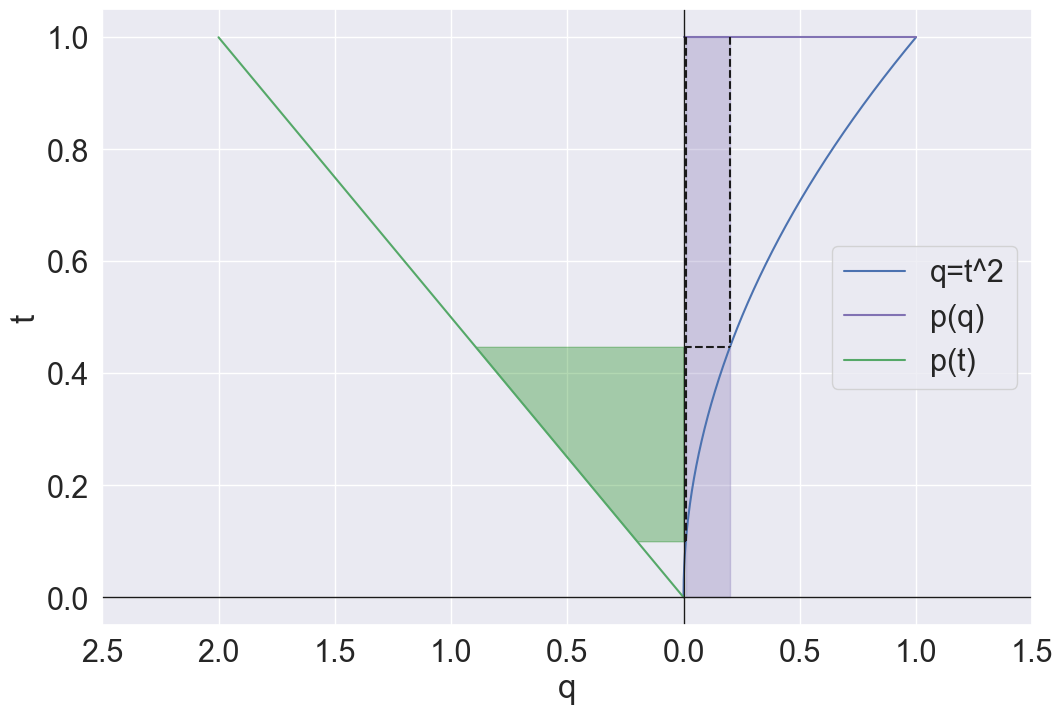

In [160]:
plt.figure(figsize=(12, 8));

plt.plot(q, t, label="q=t^2", color="b")
plt.plot(q, prior(q), label="p(q)", color="m")
plt.plot(- prior(q) * transformation_derivative(t), t, label="p(t)", color="g")

plt.xlabel("q")
plt.ylabel("t")

q_segment = np.linspace(0.01, 0.2, 20)

plt.fill_between(q_segment, prior(q_segment), alpha=0.3, color="m")
plt.fill_betweenx(transformation_inverse(q_segment), -transformation_derivative(transformation_inverse(q_segment)), alpha=0.3, color='green')


plt.plot(
    [0, q_segment[0]], 
    [transformation_inverse(q_segment[0]), transformation_inverse(q_segment[0])], 
    color="k", linestyle='--'
)
plt.plot(
    [0, q_segment[-1]], 
    [transformation_inverse(q_segment[-1]), transformation_inverse(q_segment[-1])], 
    color="k", linestyle='--'
)

plt.plot(
    [q_segment[0], q_segment[0]], 
    [prior(q_segment[0]), transformation_inverse(q_segment[0])], 
    color="k", linestyle='--'
)
plt.plot(
    [q_segment[-1], q_segment[-1]], 
    [prior(q_segment[-1]), transformation_inverse(q_segment[-1])], 
    color="k", linestyle='--'
)

plt.axvline(0, linewidth=1, color='k', alpha=1)
plt.axhline(0, linewidth=1, color='k', alpha=1)

xticts = plt.xticks()[0]
plt.xticks(xticts, np.abs(xticts))
plt.legend()
plt.show()

## Conclusion

1. MLE is invariant under reparameterization, meaning that the result remains the same regardless of how the parameter is represented.
2. MAP is not invariant under reparameterization, meaning that the choice of parameterization can significantly affect the results.
